<div style="
    background-color:#eef6ff;
    border-left:6px solid #1f77b4;
    padding:18px 24px;
    border-radius:14px;
    font-size:26px;
    font-weight:700;
    color:#0b3c5d;
    width: fit-content;
">
📞 Telecom Customer Churn Prediction & Analysis
</div>



### 📉 Problem: Customer Churn Prediction

Customer churn is a **critical and painful loss** for any company. When customers leave at scale, it directly impacts **revenue, brand trust, and long-term sustainability**—to the point where the company’s future can be seriously at risk.

In this project, we work with a **telecom customer churn dataset from Kaggle**. The objective is not just to build a model, but to **deeply engage with the data** by:

- Cleaning and preprocessing raw customer information  
- Understanding customer behavior through exploratory data analysis (EDA)  
- Identifying key factors that influence churn  
- Building and evaluating machine learning models to **predict customer churn**

By transforming raw data into meaningful insights and predictive signals, the goal is to help the business **identify at-risk customers early** and take proactive retention actions before churn occurs.


## Basic imports

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning)

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

train = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mnassrib/telecom-churn-datasets",
    'churn-bigml-80.csv'
)
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mnassrib/telecom-churn-datasets",
    'churn-bigml-20.csv'
)

## Data overview

In [3]:
print("train shape: ",train.shape)
print("test shape: ",test.shape)

train shape:  (2666, 20)
test shape:  (667, 20)


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

| Column                    | Type                        | Meaning                                     | Churn Insight                         |
| ------------------------- | --------------------------- | ------------------------------------------- | ------------------------------------- |
| **State**                 | Categorical                 | Customer’s US state                         | Usually weak signal; high-cardinality |
| **Account length**        | Numeric                     | How long the account has been active (days) | Longer tenure → lower churn           |
| **Area code**             | Categorical (numeric-coded) | Phone area code                             | Often weak / noisy                    |
| **International plan**    | Binary (Yes/No)             | Has international calling plan              | Strong churn signal (higher bills)    |
| **Voice mail plan**       | Binary (Yes/No)             | Has voicemail service                       | Customers without it churn more       |
| **Number vmail messages** | Numeric                     | Voicemail usage                             | Proxy for engagement                  |
| **Total day minutes** | Continuous | Daytime call duration | High usage → bill sensitivity |
| **Total day calls**   | Count      | Number of day calls   | Weak alone                    |
| **Total day charge**  | Continuous | Charges for day calls | **Redundant** with minutes    |
| **Total eve minutes** | Continuous | Evening call duration | Moderate importance |
| **Total eve calls**   | Count      | Evening calls count   | Low                 |
| **Total eve charge**  | Continuous | Evening charges       | Redundant           |
| **Total night minutes** | Continuous | Night call duration | Usually weak  |
| **Total night calls**   | Count      | Night calls count   | Very weak     |
| **Total night charge**  | Continuous | Night charges       | Redundant     |
| **Total intl minutes** | Continuous | International call minutes   | Important     |
| **Total intl calls**   | Count      | International call frequency | Important     |
| **Total intl charge**  | Continuous | Intl call charges            | Redundant     |
| **Customer service calls** | Count | Support call frequency | **Very strong churn predictor** |
| **Churn** | Boolean | Whether customer left |


In [6]:
train.sample(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
2164,NV,92,415,No,Yes,44,152.0,95,25.84,274.9,73,23.37,162.4,121,7.31,10.0,1,2.70,2,False
245,RI,112,510,No,No,0,194.4,101,33.05,190.3,82,16.18,183.4,107,8.25,11.4,2,3.08,0,False
1809,FL,113,510,No,No,0,92.6,85,15.74,177.6,92,15.10,159.8,72,7.19,14.4,4,3.89,3,False
2658,IN,117,415,No,No,0,118.4,126,20.13,249.3,97,21.19,227.0,56,10.22,13.6,3,3.67,5,True
2471,WV,88,510,No,No,0,131.5,99,22.36,174.8,128,14.86,184.2,83,8.29,7.9,2,2.13,5,True


In [7]:
train['Churn'] = train['Churn'].astype(int)
train['International plan'] = train['International plan'].map({'Yes': 1, 'No': 0})
train['Voice mail plan'] = train['Voice mail plan'].map({'Yes': 1, 'No': 0})

In [8]:
train

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,0
2662,AZ,192,415,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,0
2663,WV,68,415,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,0
2664,RI,28,510,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,0


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Voice mail plan         2666 non-null   int64  
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [10]:
train.drop(['State','Area code'],axis=1,inplace=True)

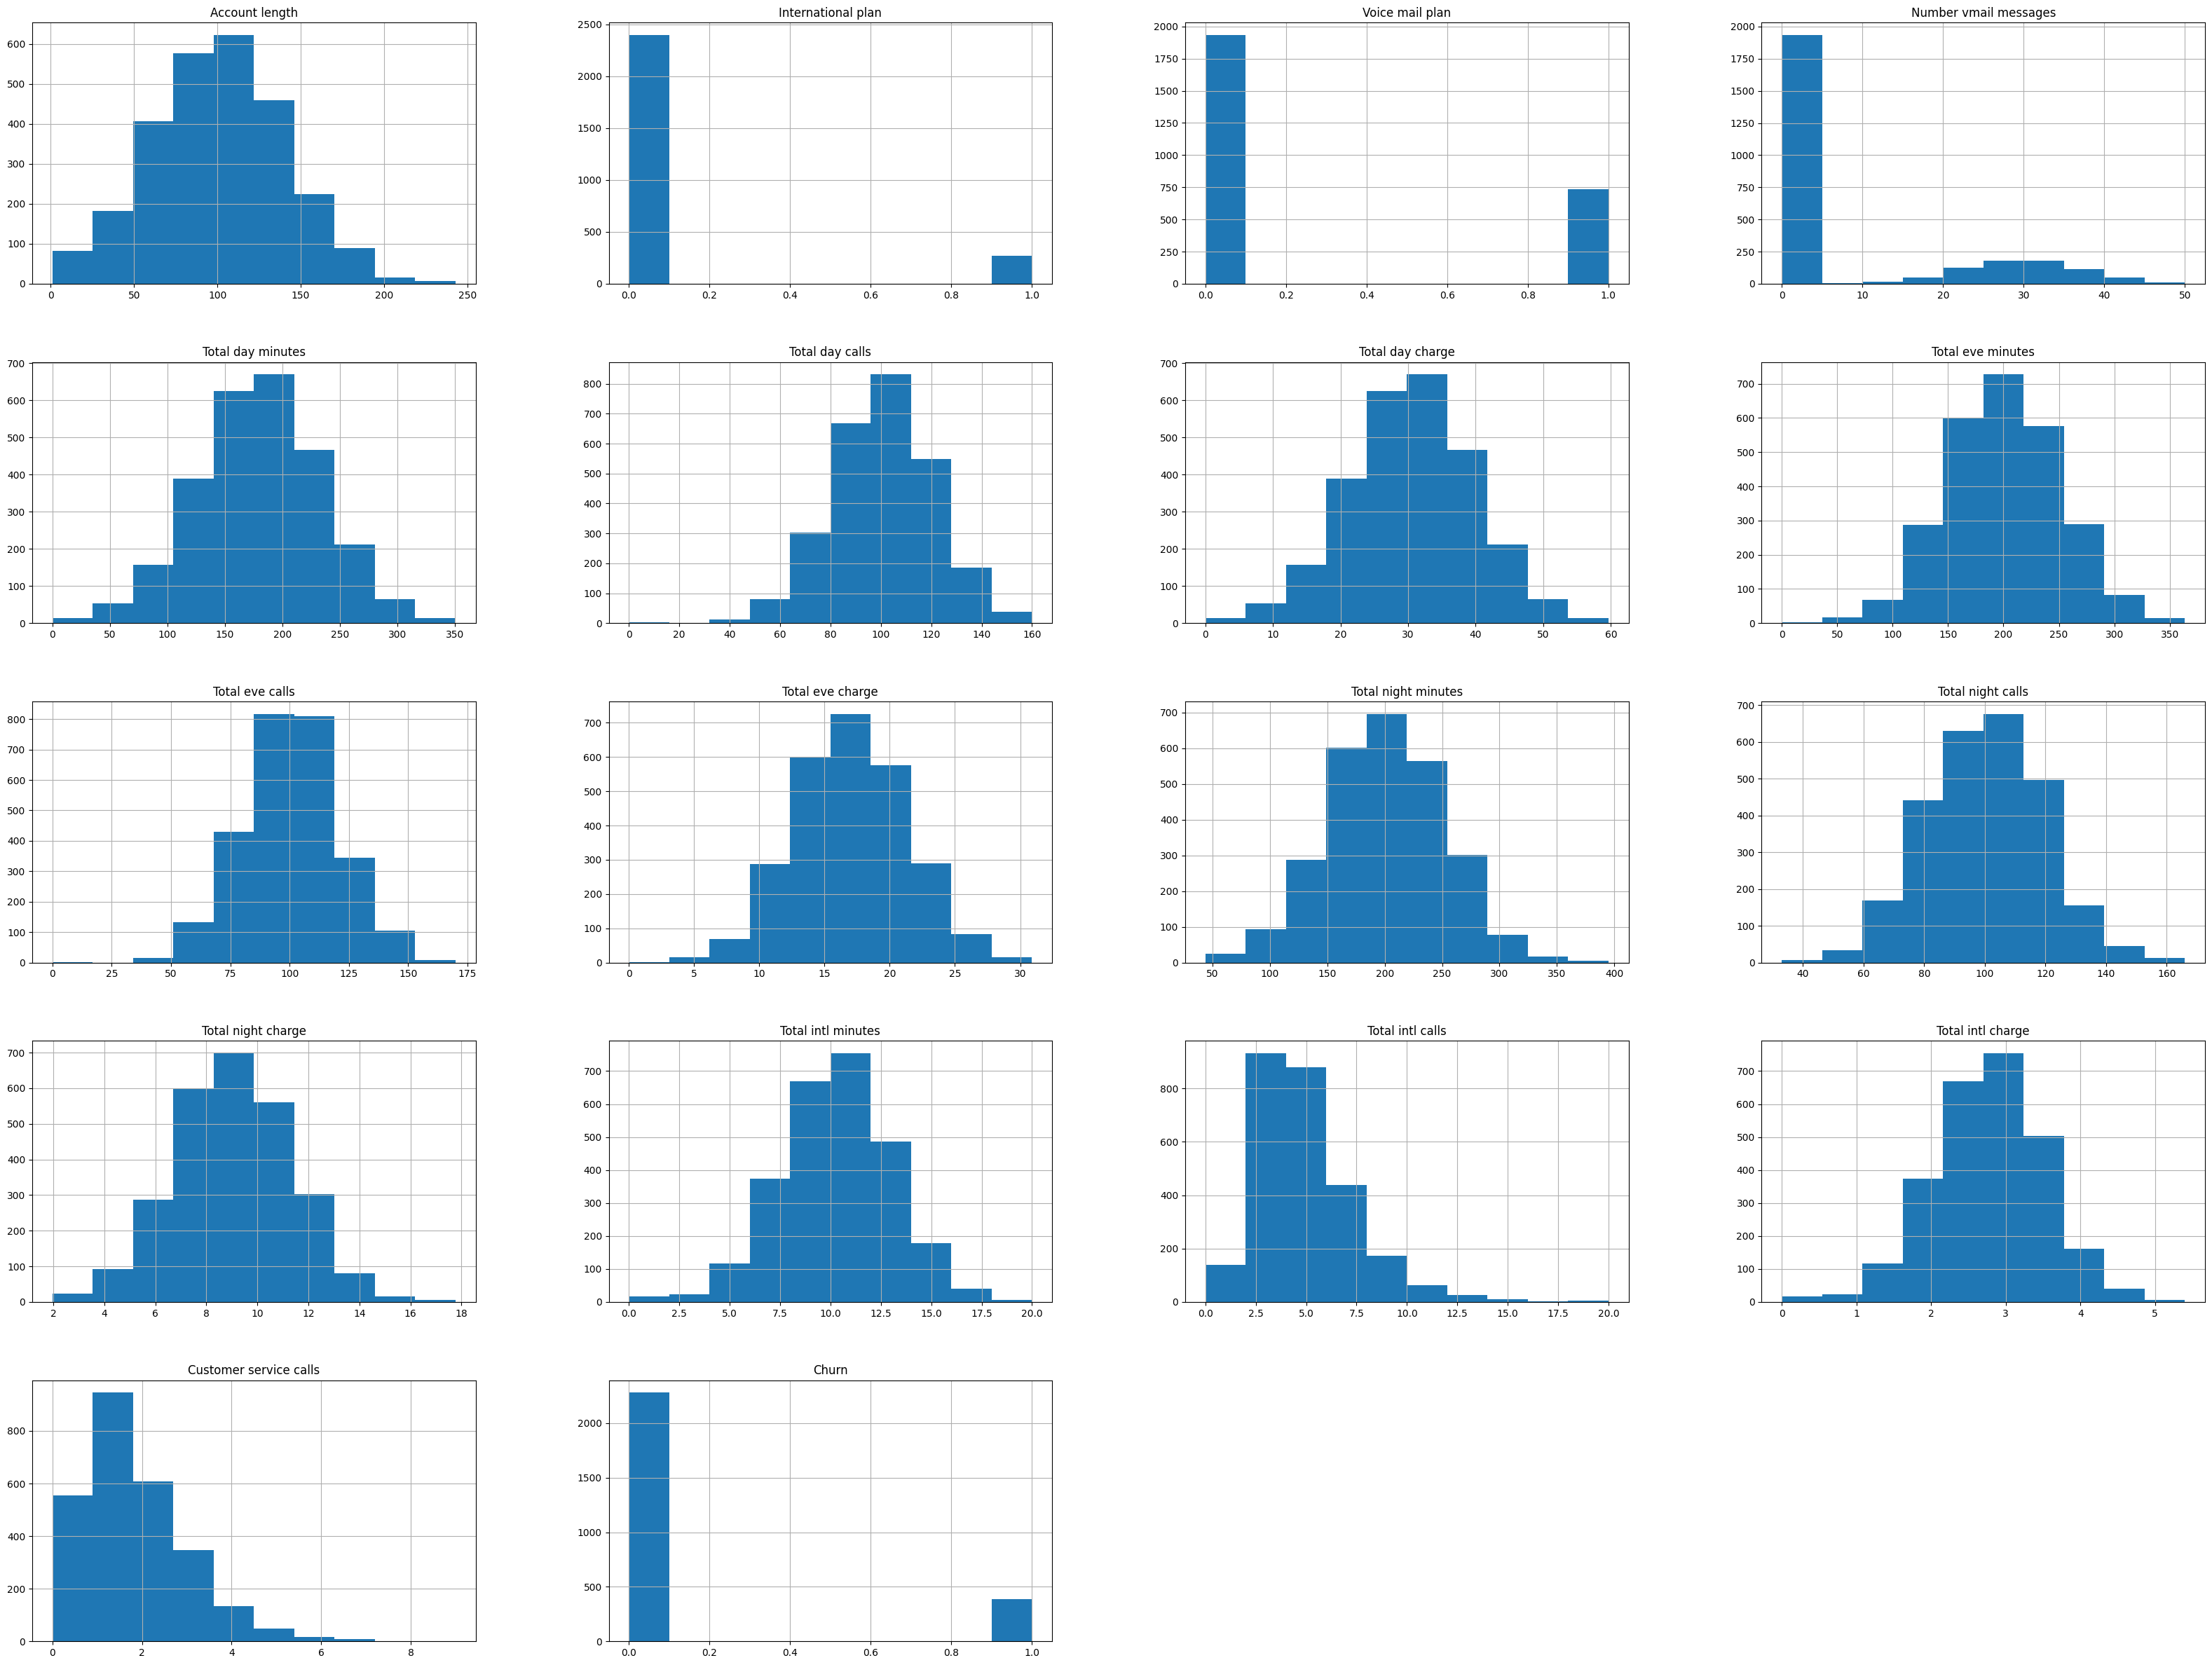

In [11]:
train.select_dtypes(exclude=object).hist(figsize=(40,30))
plt.show()

In [12]:
def distribution_plot(df, col, hue='Churn', plot='kde', bins='auto'):
    
    bins = bins if bins == 'auto' else int(bins)

    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    if plot == 'kde':
        sns.kdeplot(data=df, x=col, ax=axes[0])
        axes[0].set_title(f"{col} Distribution")

        sns.kdeplot(data=df, x=col, hue=hue, fill=True, ax=axes[1])
        axes[1].set_title(f"{col} vs {hue}")

    elif plot == 'hist':
        sns.histplot(data=df, x=col, bins=bins, ax=axes[0])
        axes[0].set_title(f"{col} Distribution")

        sns.histplot(data=df, x=col, hue=hue, bins=bins, ax=axes[1])
        axes[1].set_title(f"{col} vs {hue}")

    elif plot == 'count':
        sns.countplot(data=df, x=col, ax=axes[0])
        axes[0].set_title(f"{col} Distribution")

        sns.heatmap(
            pd.crosstab(df[col], df[hue]),
            annot=True,
            fmt='d',
            ax=axes[1]
        )
        axes[1].set_title(f"{col} vs {hue}")
    else:
        print("Invald plot")

    plt.tight_layout()
    plt.show()

In [13]:
train.head()

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [14]:
train.columns

Index(['Account length', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')

In [15]:
numCols = ['Account length','Number vmail messages' ,'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge']

In [16]:
len(numCols)

14

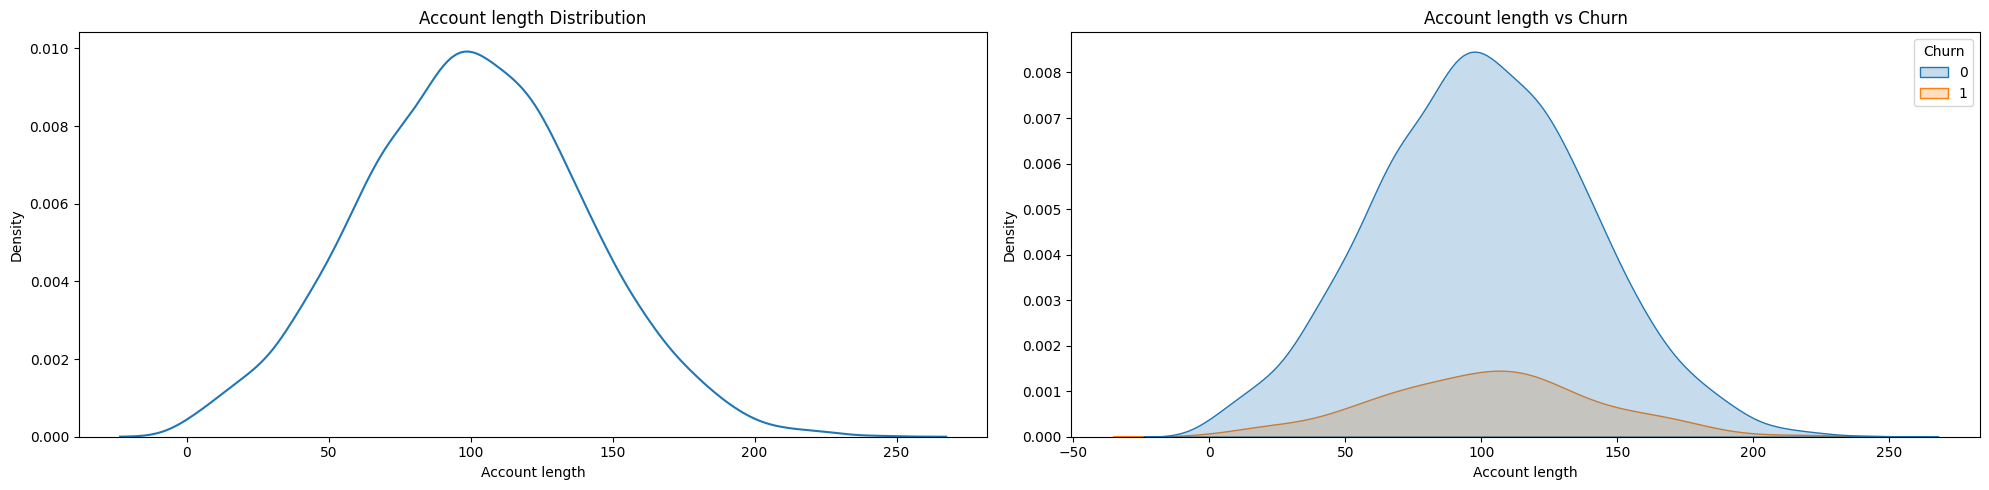

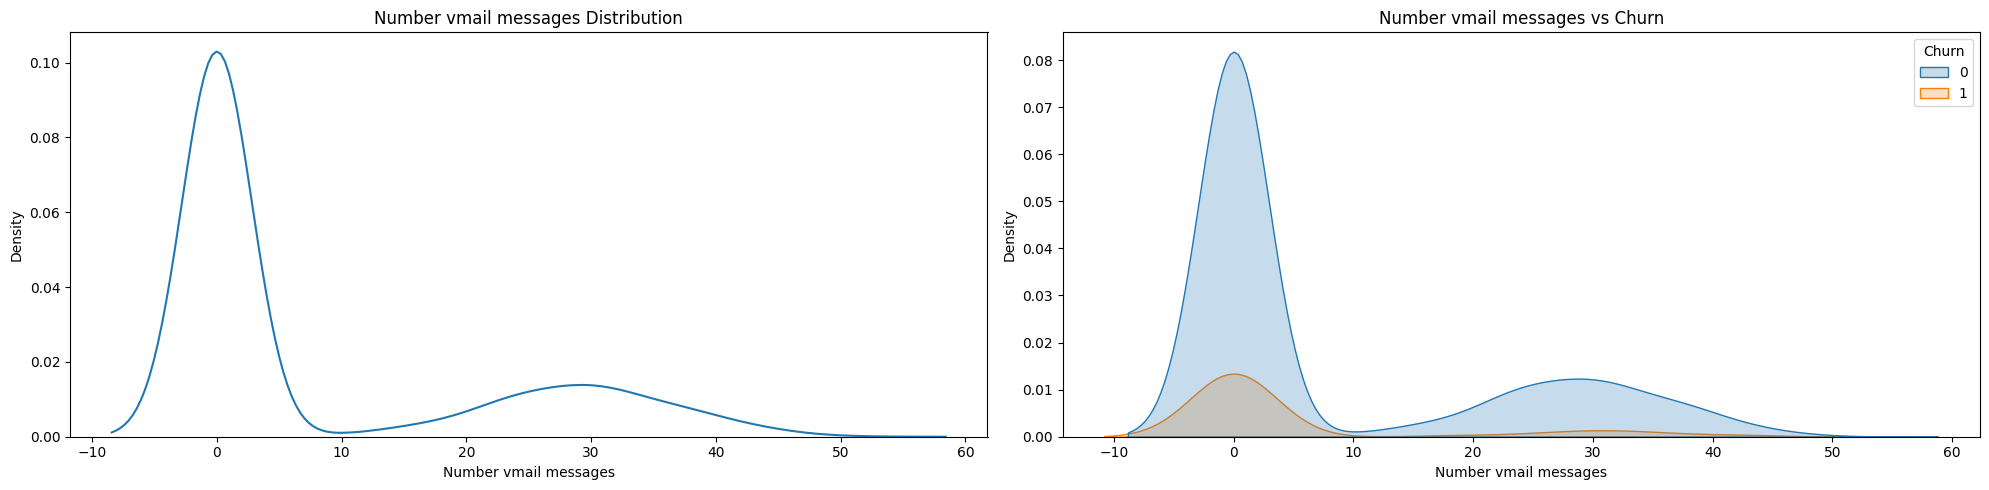

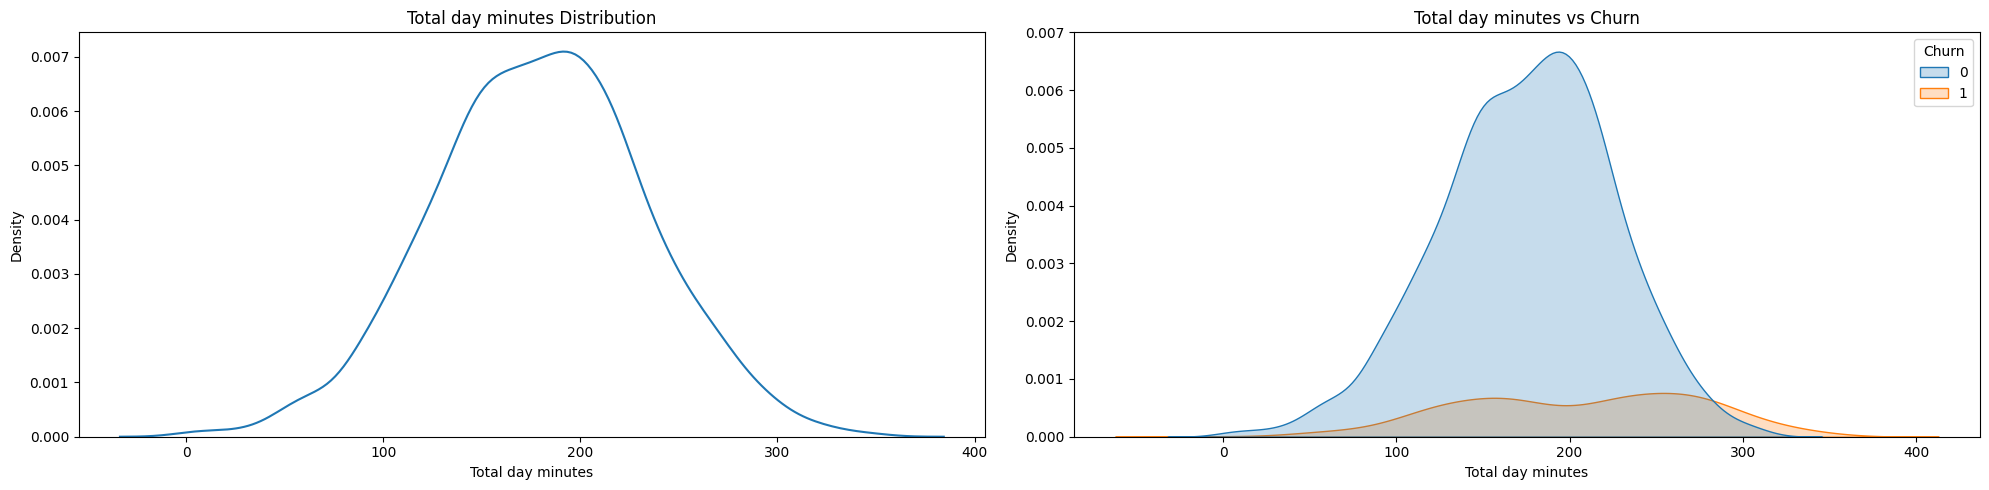

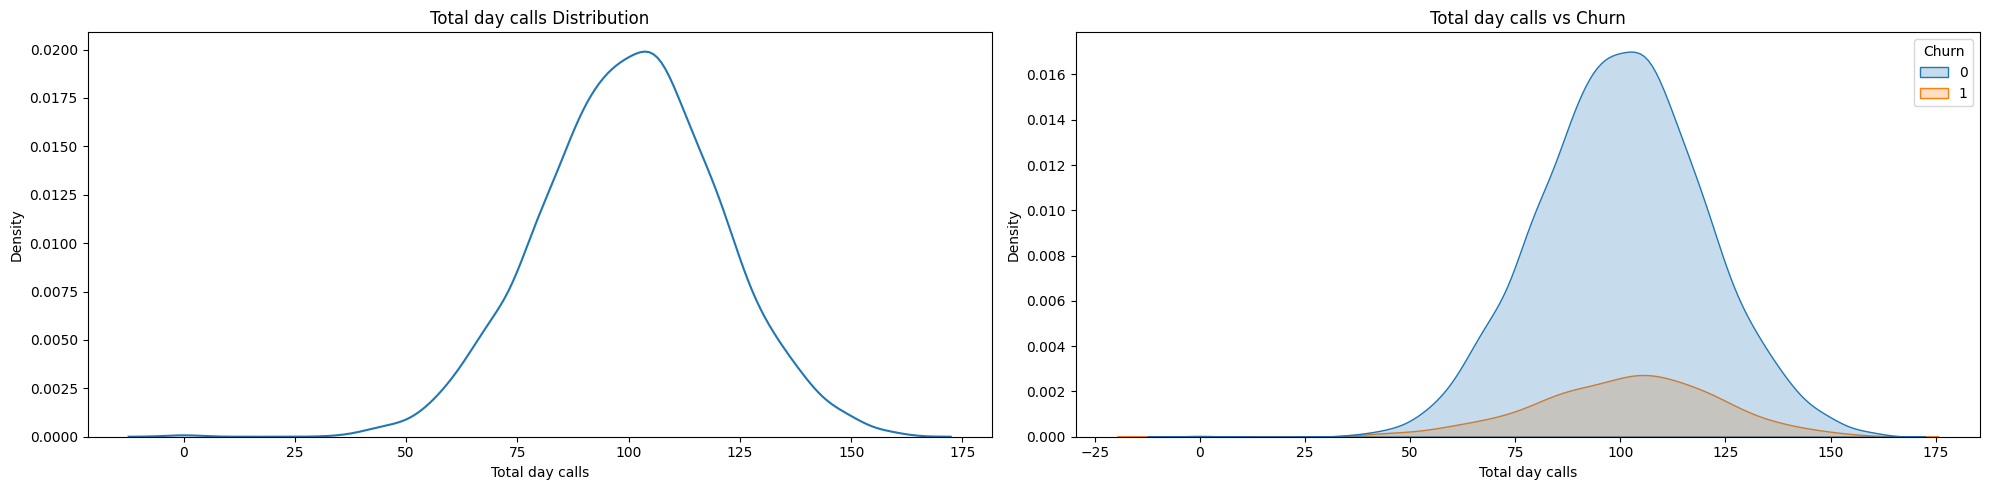

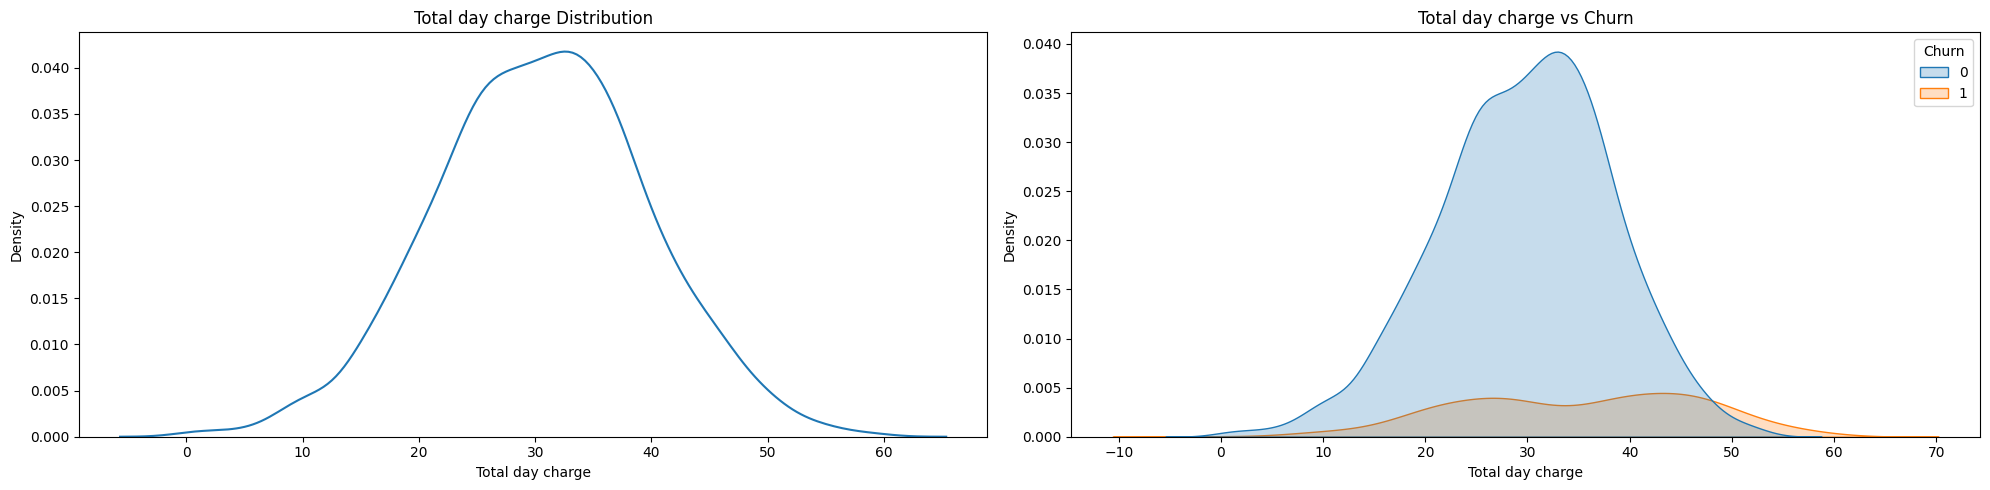

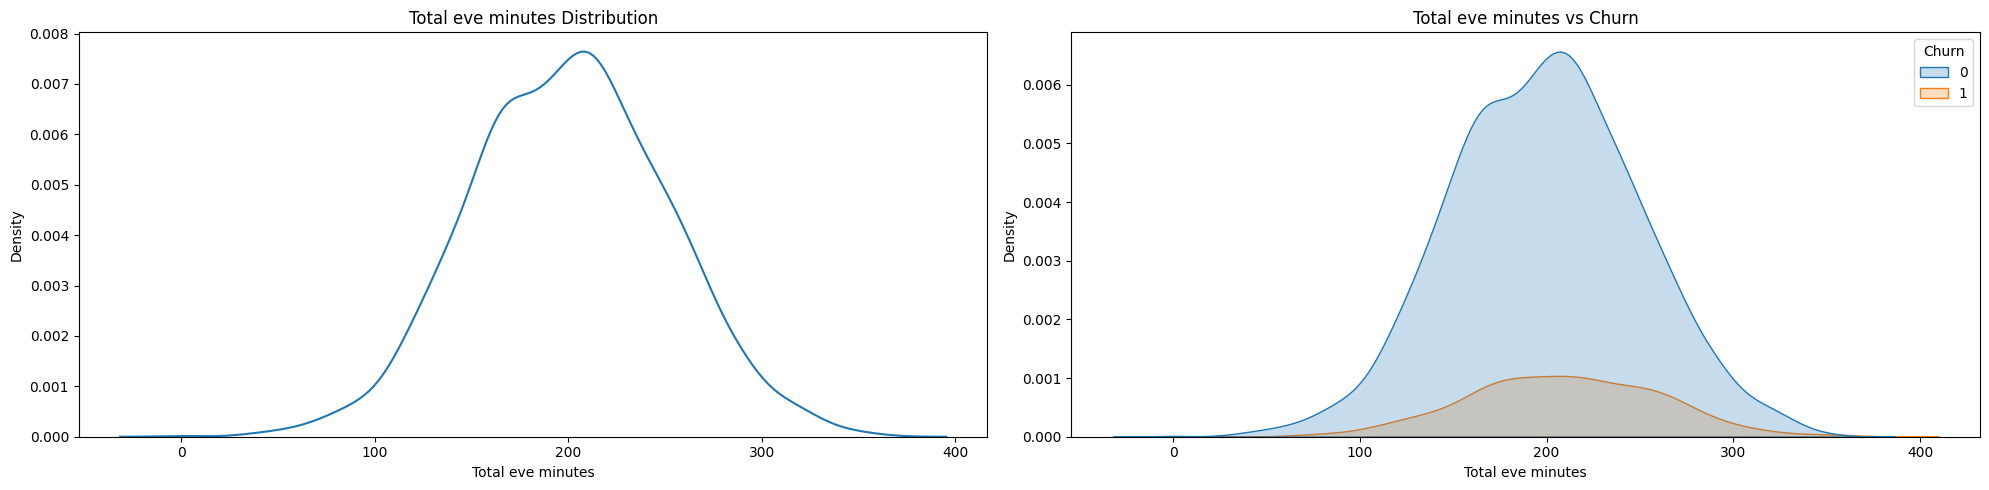

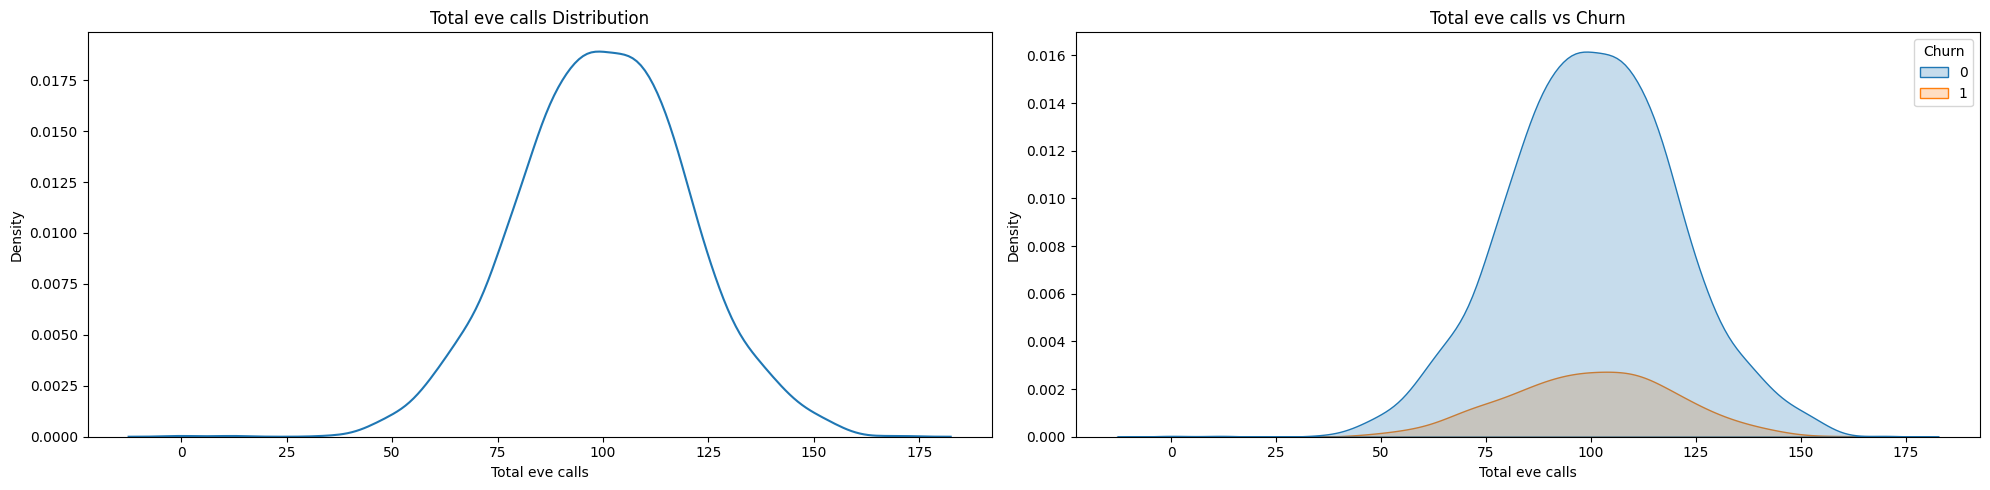

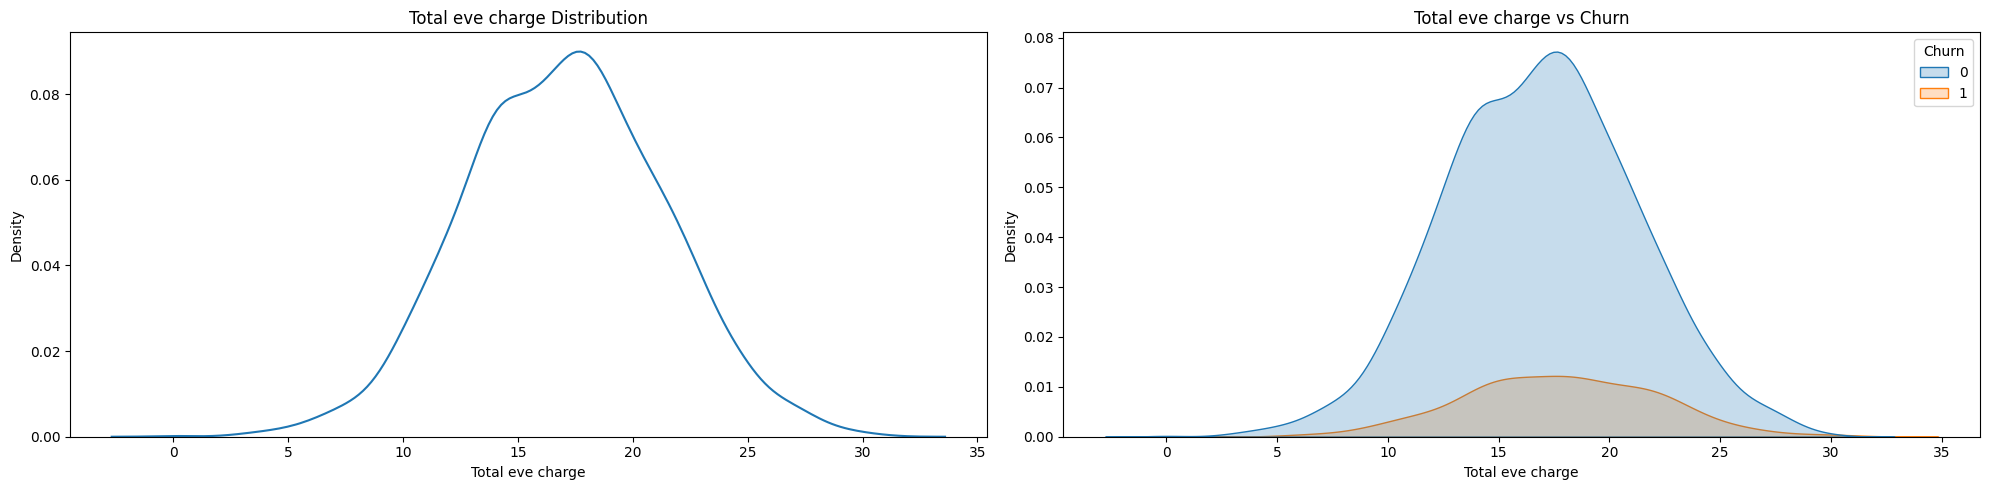

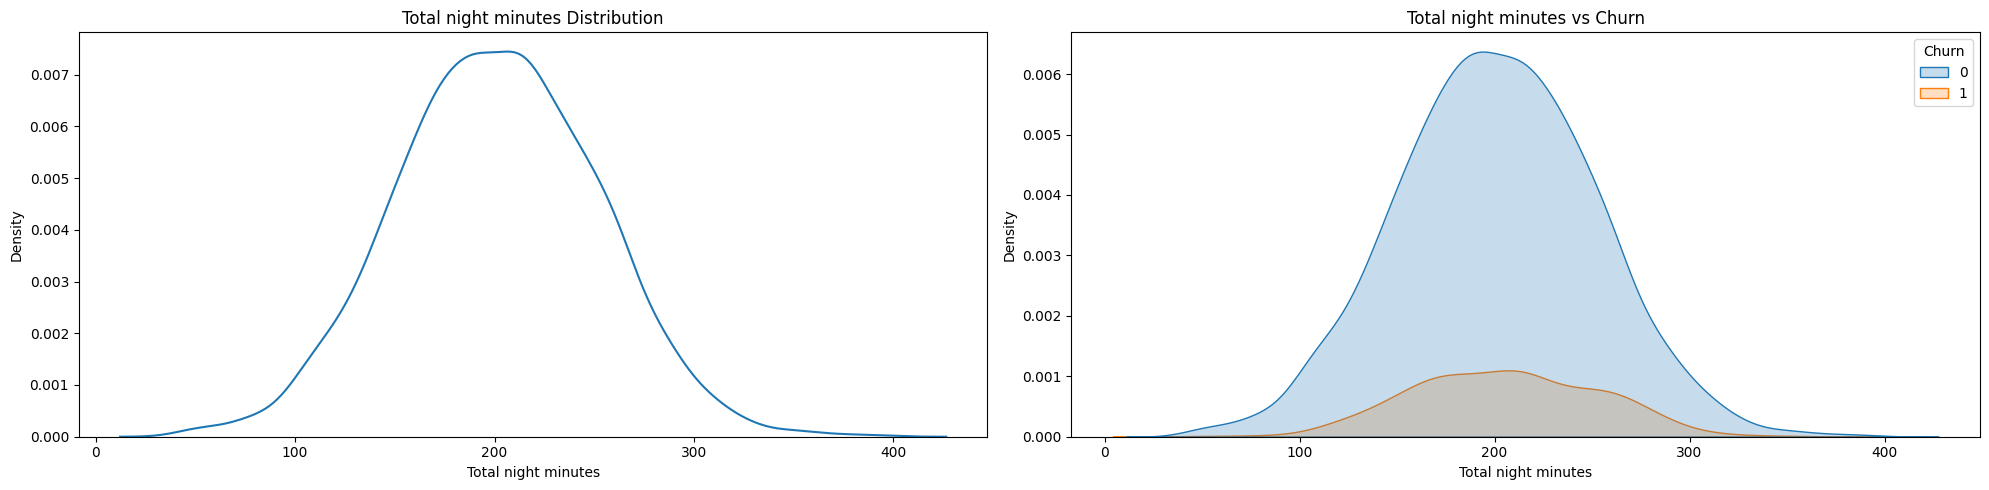

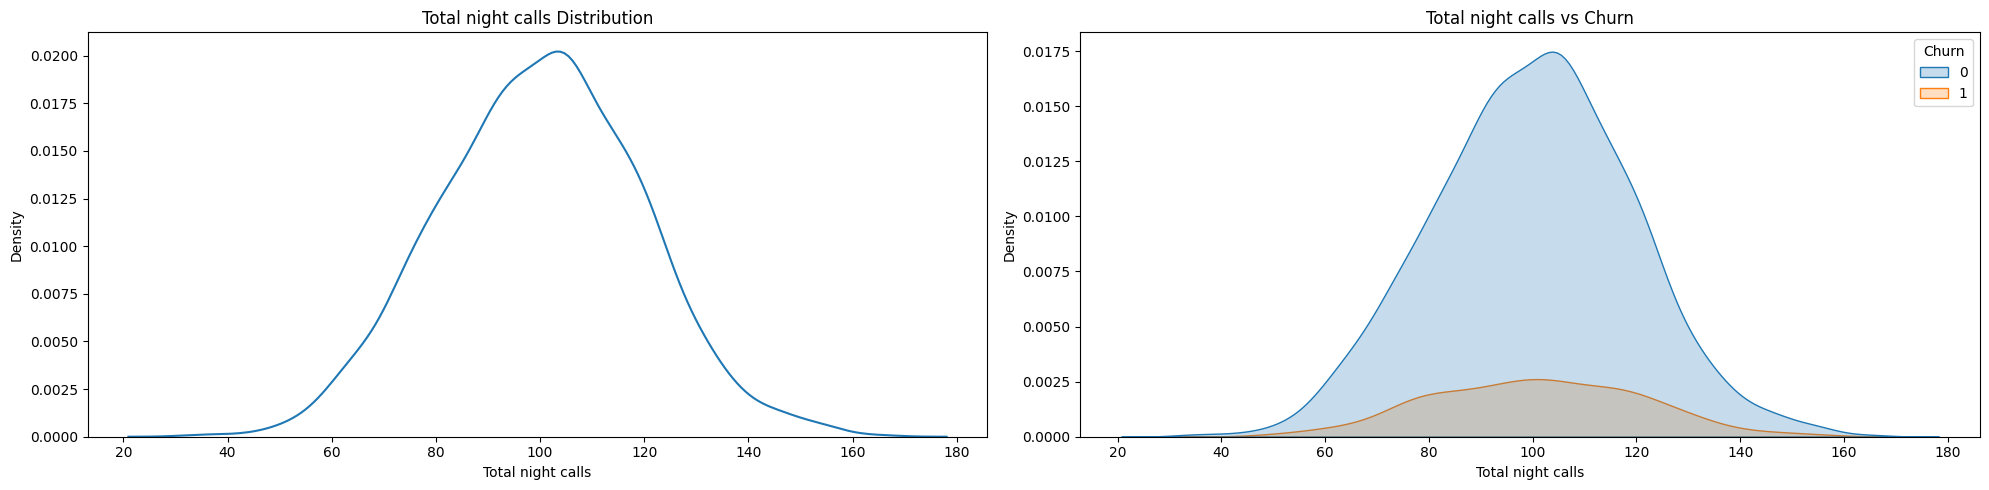

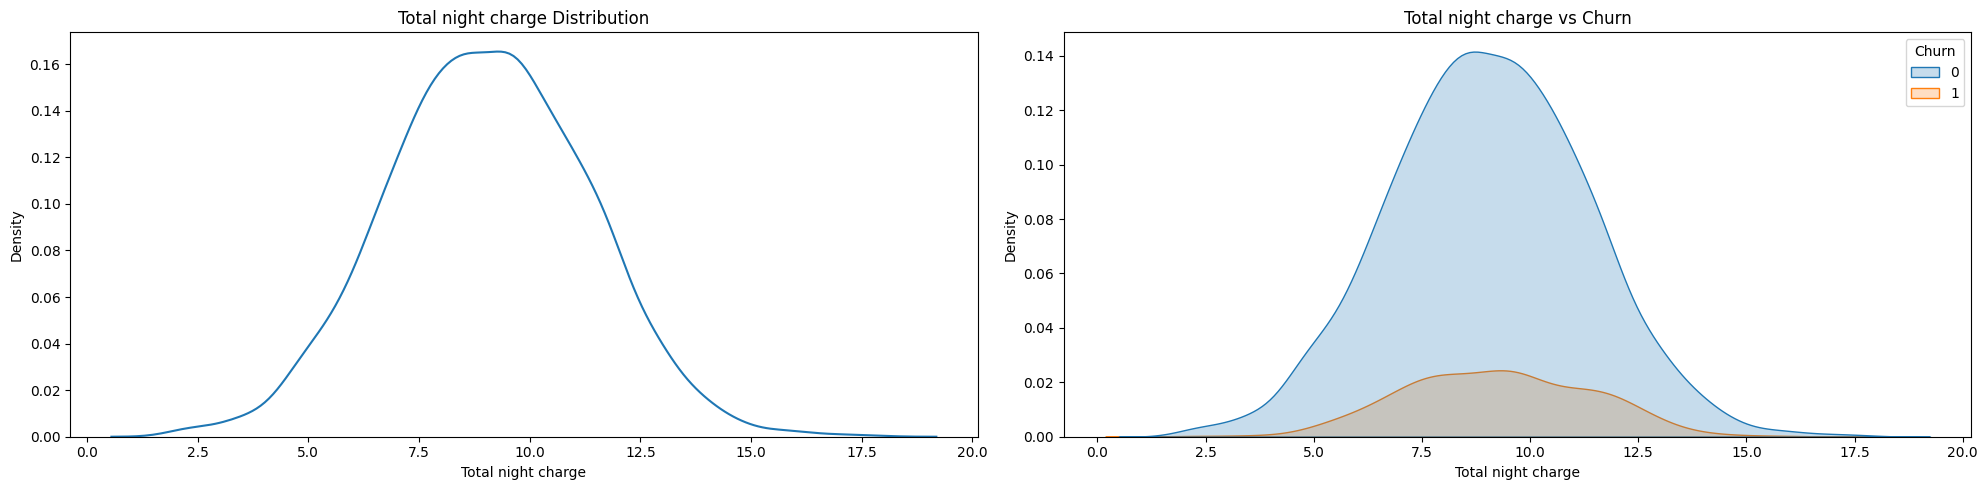

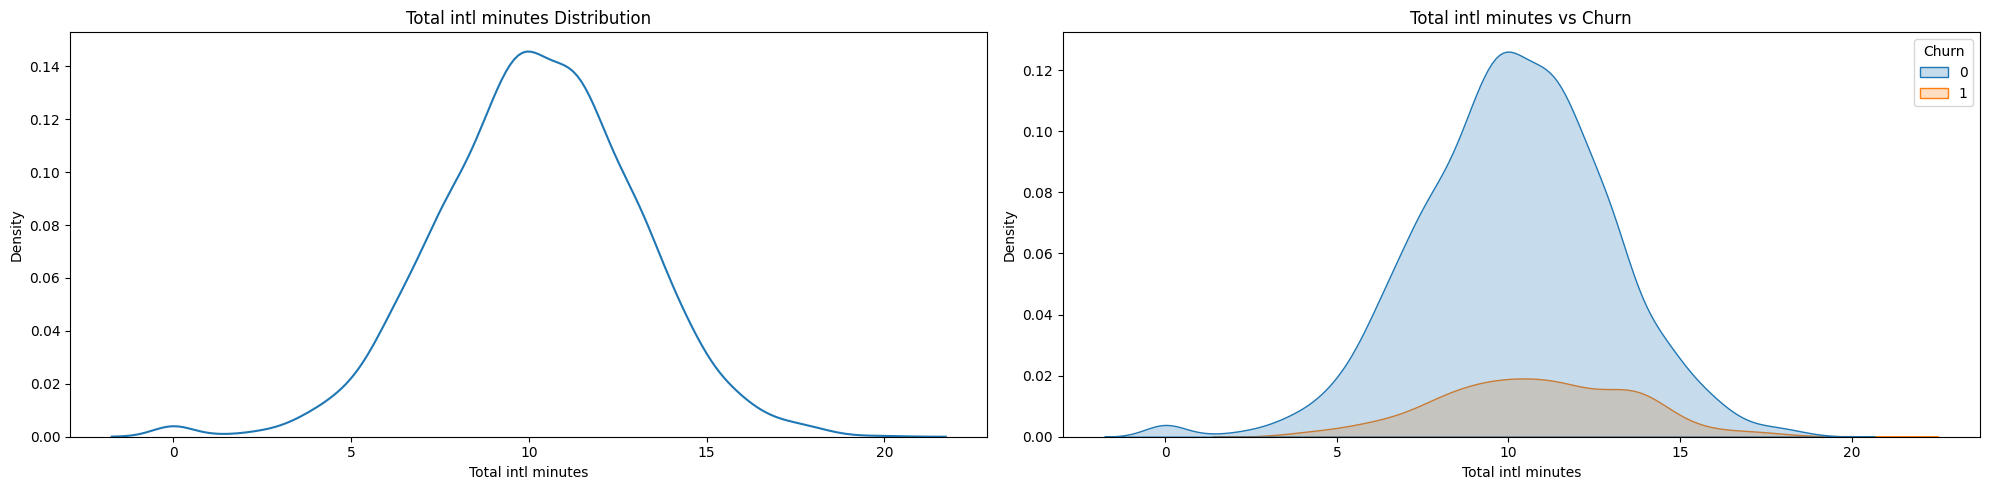

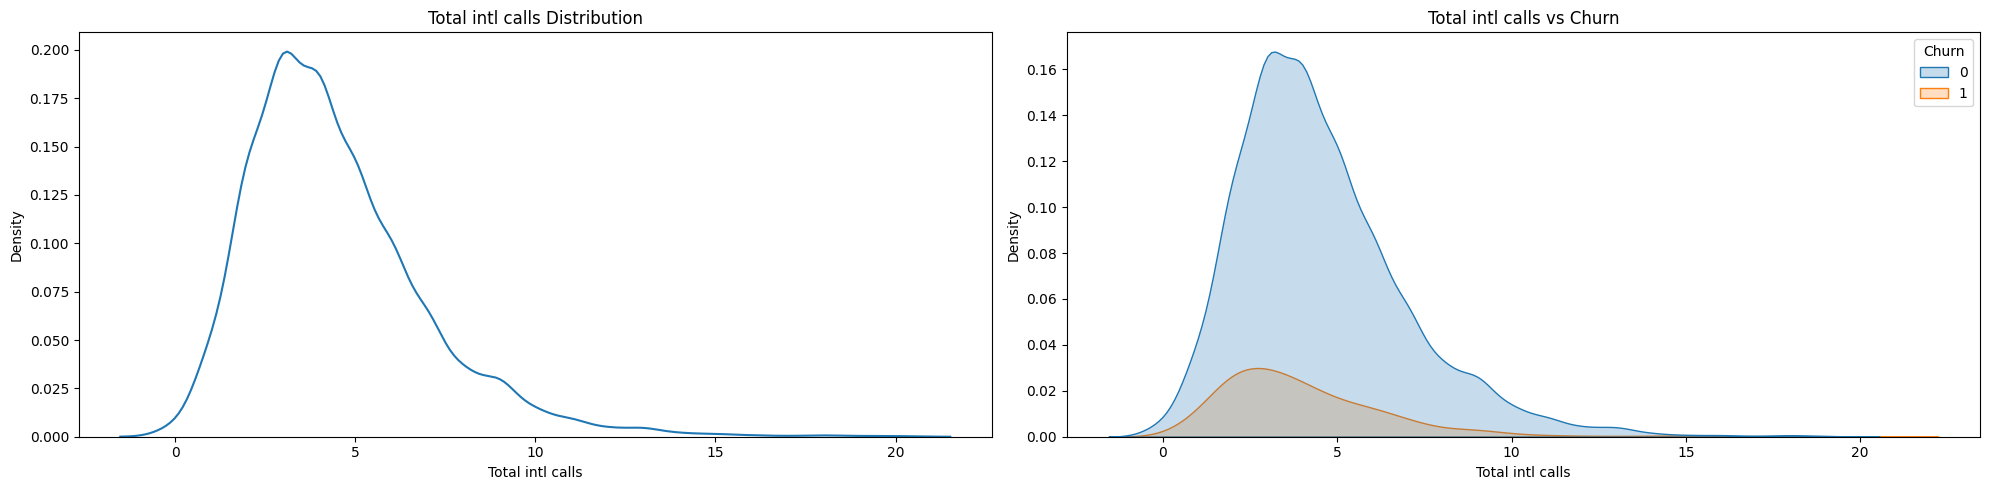

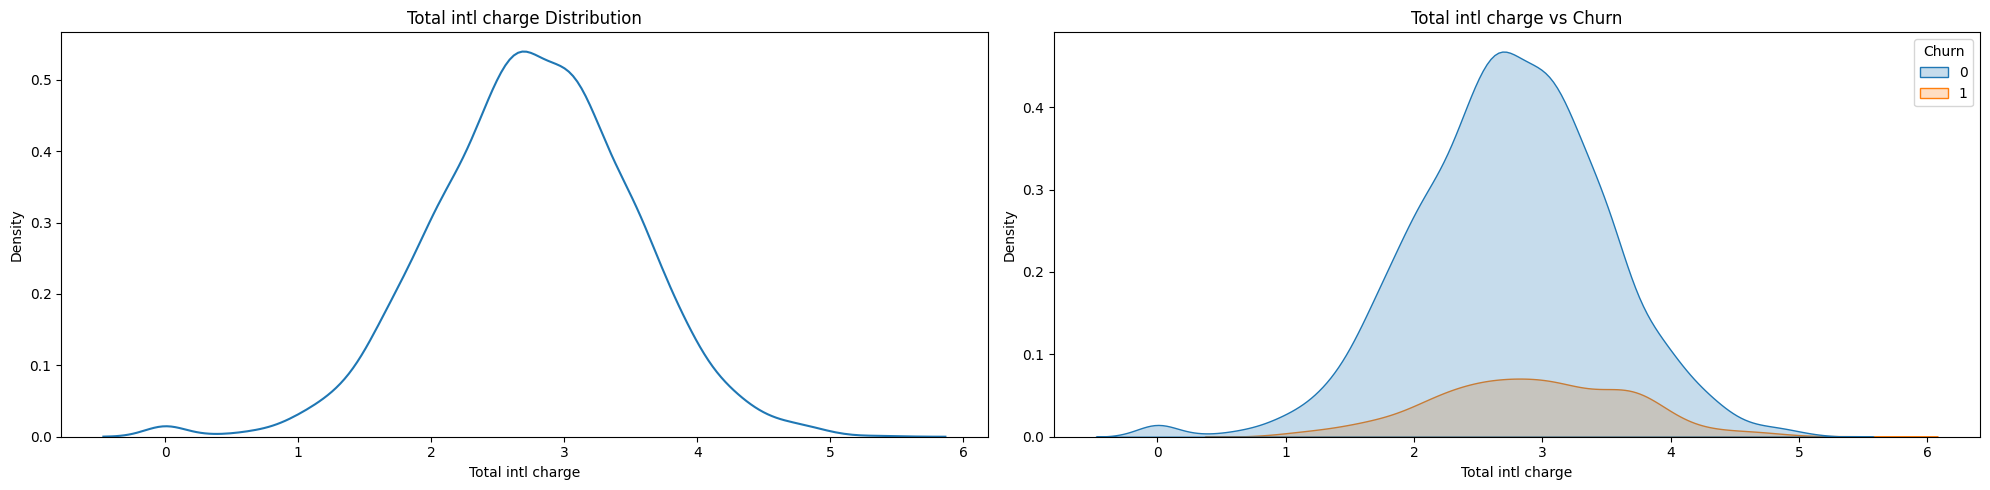

In [17]:
for col in numCols:
    distribution_plot(train,col=col,plot='kde')

# 📊 Customer Churn – Complete EDA Summary

This exploratory data analysis (EDA) examines customer behavior across **tenure, voicemail usage, call patterns, usage intensity, charges, and international activity**, and evaluates how these factors relate to **customer churn**.

---

## 🧾 1. Account Length
- **Distribution:** Approximately normal, centered around mid-range tenure.
- **Churn Relationship:** Strong overlap between churned and non-churned customers.
- **Insight:**  
  - Account length alone is a **weak churn predictor**.  
  - Newer customers show slightly higher churn, but the effect is limited.

---

## 📬 2. Number of Voicemail Messages
- **Distribution:** Strongly **bimodal**  
  - Large spike at **0** (no voicemail plan)  
  - Second peak around **25–30** messages
- **Churn Relationship:**  
  - Customers with **0 voicemail messages** churn more.  
  - Active voicemail users are **more stable**.
- **Insight:**  
  - Strong indicator of **customer engagement**  
  - One of the **best churn predictors**

---

## ☀️ 3. Daytime Usage

### Total Day Minutes
- **Distribution:** Near-normal.
- **Churn Relationship:**  
  - Churned customers tend to have **higher usage**.
- **Insight:**  
  - High daytime usage → **bill shock risk → churn**.

### Total Day Calls
- **Distribution:** Normal.
- **Churn Relationship:** Minimal separation.
- **Insight:**  
  - Call frequency alone is a **weak churn signal**.

### Total Day Charge
- **Insight:**  
  - Perfectly correlated with total day minutes.  
  - **Drop charges or minutes (not both)** to avoid multicollinearity.

---

## 🌆 4. Evening Usage
- **Minutes, Calls, Charges:** Approximately normal distributions.
- **Churn Relationship:** Heavy overlap across churn classes.
- **Insight:**  
  - Evening usage has **low impact on churn**.  
  - Charges are redundant with minutes.

---

## 🌙 5. Night Usage
- **Minutes, Calls, Charges:** Symmetric distributions.
- **Churn Relationship:** Almost identical curves for churned and non-churned customers.
- **Insight:**  
  - Night usage is a **negligible churn driver**.

---

## 🌍 6. International Usage

### Total International Minutes
- **Distribution:** Normal, centered around ~10 minutes.
- **Churn Relationship:**  
  - Higher international usage among churned customers.
- **Insight:**  
  - Moderate to strong churn signal.

### Total International Calls
- **Distribution:** Right-skewed.
- **Churn Relationship:**  
  - Higher call frequency corresponds to higher churn.
- **Insight:**  
  - One of the **strongest churn indicators**.

### Total International Charge
- **Insight:**  
  - Perfectly correlated with international minutes.  
  - Should be dropped to reduce redundancy.

---

## 🧠 Global Insights

### ✅ Strong Predictors
- `Customer service calls`
- `Number vmail messages`
- `Total intl calls`
- `Total intl minutes`
- `Total day minutes`

### ⚠️ Weak Predictors
- Call counts (day, evening, night)
- Night usage features
- Account length (when used alone)

### ❌ Redundant Features
- Minutes and charges are **highly correlated**.

---

## 🎯 Recommended Feature Selection

### ✔ Keep
- Account length  
- Number of voicemail messages  
- Total day minutes  
- Total international minutes  
- Total international calls  
- Customer service calls  

### ❌ Drop
- All charge-related columns  
- Most call-count features (except international calls)  
- Night usage features  

---

## 💼 Business Interpretation
- High-usage customers (especially **daytime and international**) are **price-sensitive**.
- Customers without voicemail plans are more likely to churn.
- International users benefit from **targeted plans and discounts**.
- Night usage has minimal influence on churn.

---

## 🧩 Final Conclusion
- Churn is driven more by **cost pressure and service engagement** than by tenure.
- **Usage intensity > usage frequency**.
- International calling behavior is a **key lever for churn prevention**.
----

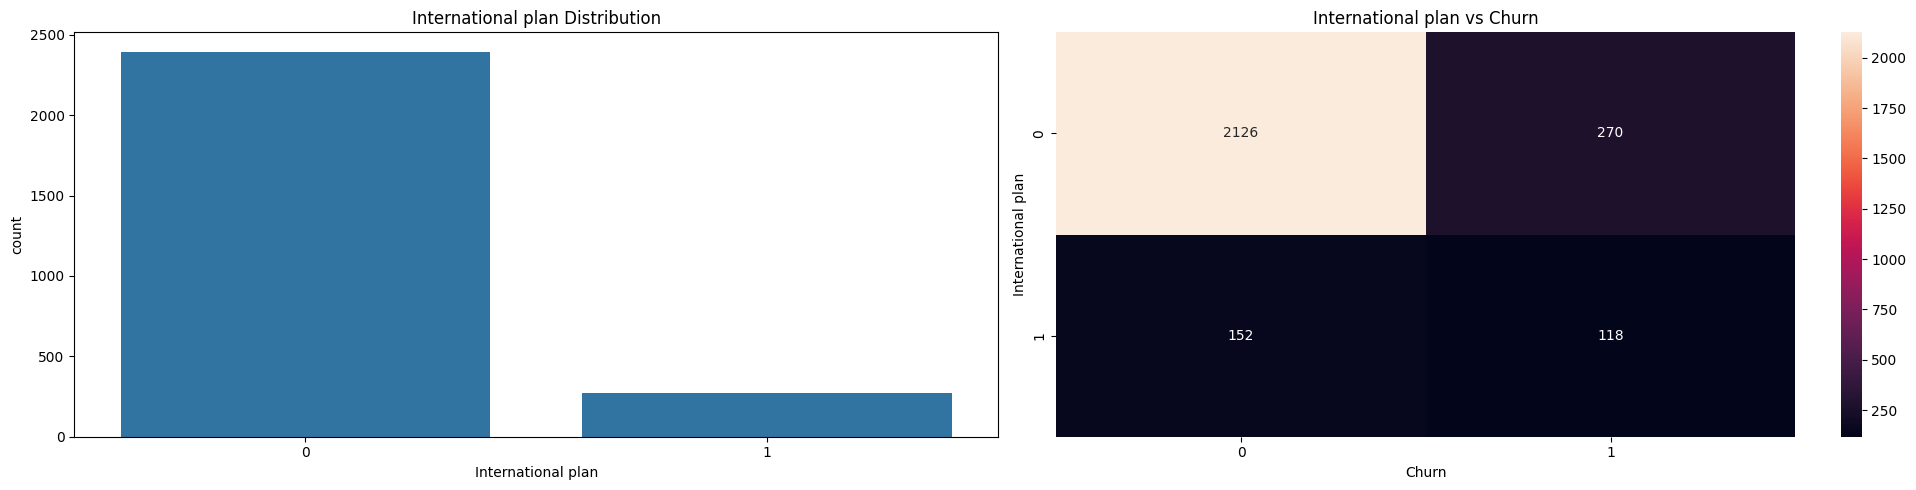

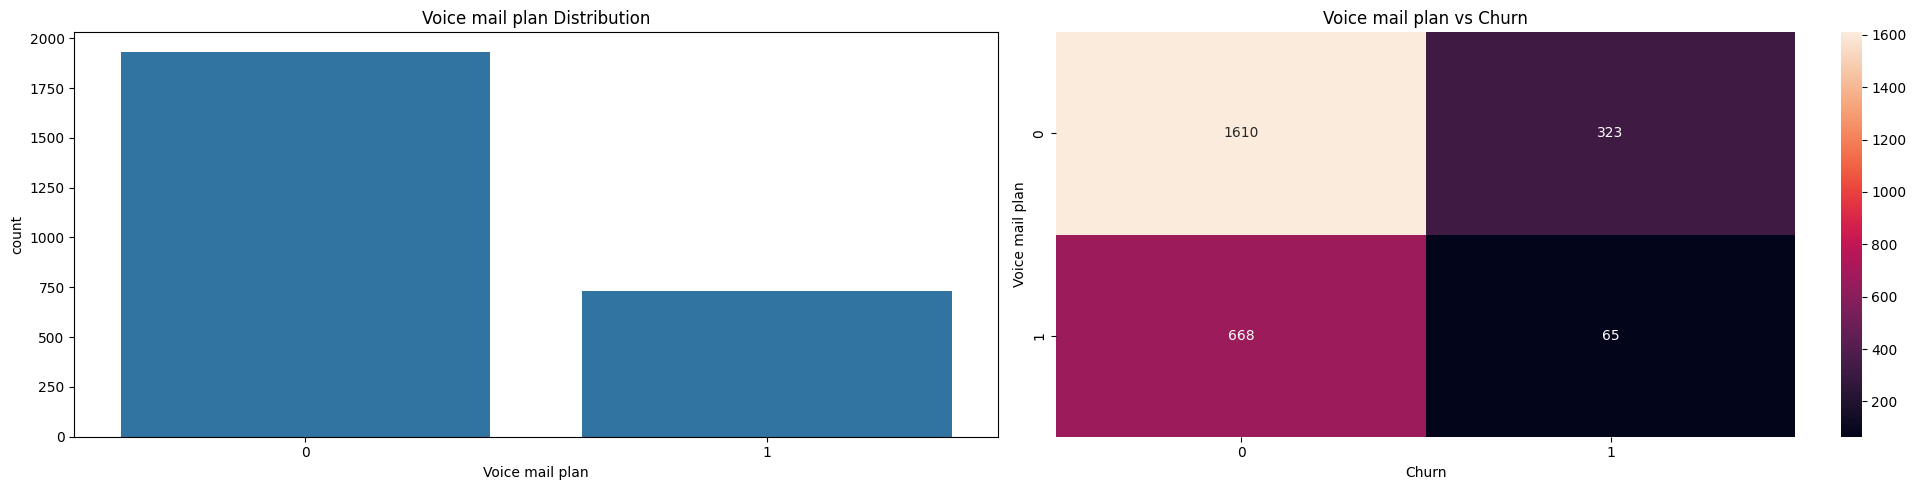

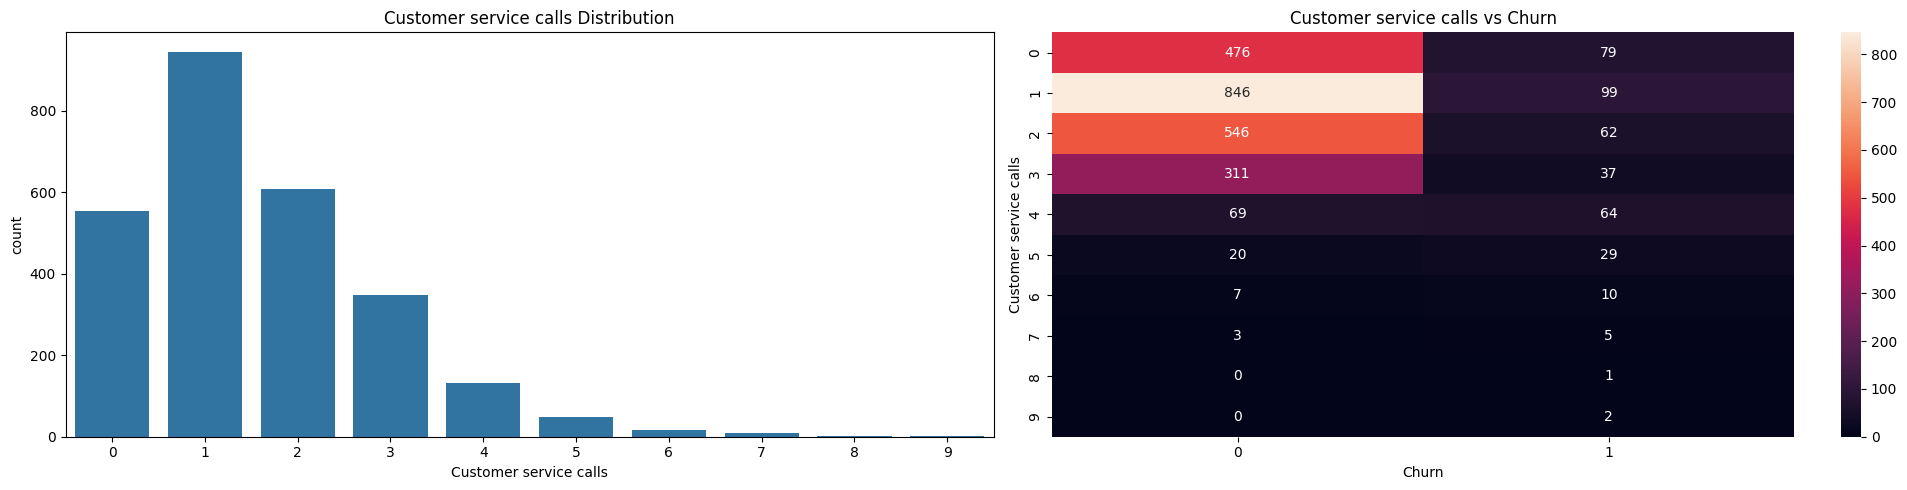

In [18]:
catCols = ['International plan','Voice mail plan','Customer service calls']
for col in catCols:
    distribution_plot(train,col=col,plot='count')

| Feature                | Effect on Churn    | Modeling Notes              |
| ---------------------- | ------------------ | --------------------------- |
| International plan     | 🔴 Increases churn | Keep as binary flag         |
| Voice mail plan        | 🟢 Reduces churn   | Strong retention signal     |
| Customer service calls | 🔥 Strong increase | Bin or create ≥4 calls flag |


In [19]:
train['high_service_calls'] = (train['Customer service calls']>=4).astype(int)

In [20]:
train.head(0)

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,high_service_calls


##  Telecom Data Preprocessing & Feature Engineering Transformer


In [22]:
class TeleComTransformer(BaseEstimator,TransformerMixin):
    def __init__(self,dropCols=None,service_call_threshold=4):
        self.dropCols  = dropCols
        self.service_call_threshold=service_call_threshold
        self.map_ = {"Yes":1,'No':0}
        self.mapCols_ = ['International plan','Voice mail plan']
        
    def fit(self,X,y=None):
        self.is_fitted_ = True
        return self
    def transform(self,X):
        check_is_fitted(self,'is_fitted_')
        X = X.copy()
        for col in self.mapCols_:
            X[col]=X[col].map(self.map_)
            
        X['highServiceCalls'] = (X['Customer service calls']>=self.service_call_threshold).astype(int)
        dropCols = self.dropCols or ['State','Area code','Total day charge',
                               'Total eve charge','Total night charge',
                               'Total intl charge','Total day calls',
                               'Total eve calls','Total night calls',
                               'Total eve minutes','Total night minutes'
                              ]
        return X.drop(columns=dropCols)
        


In [23]:
train = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mnassrib/telecom-churn-datasets",
    'churn-bigml-80.csv'
)
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mnassrib/telecom-churn-datasets",
    'churn-bigml-20.csv'
)

In [24]:
transformer = TeleComTransformer().fit(train)

In [25]:
train_tsf = transformer.transform(train)
test_tsf = transformer.transform(test)

In [26]:
train_tsf

,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total intl minutes,Total intl calls,Customer service calls,Churn,highServiceCalls
0,128,0,1,25,265.1,10.0,3,1,False,0
1,107,0,1,26,161.6,13.7,3,1,False,0
2,137,0,0,0,243.4,12.2,5,0,False,0
3,84,1,0,0,299.4,6.6,7,2,False,0
4,75,1,0,0,166.7,10.1,3,3,False,0
...,...,...,...,...,...,...,...,...,...,...
2661,79,0,0,0,134.7,11.8,5,2,False,0
2662,192,0,1,36,156.2,9.9,6,2,False,0
2663,68,0,0,0,231.1,9.6,4,3,False,0
2664,28,0,0,0,180.8,14.1,6,2,False,0


In [33]:
models = {
    'lgr':LogisticRegression(max_iter=400),
    'dt':DecisionTreeClassifier(random_state=42),
    'rf':RandomForestClassifier(random_state=42),
    'gb':GradientBoostingClassifier(random_state=42)
    
}

In [34]:
def model_evaluation_report (y_true,y_pred):
    print("accuracy: ",accuracy_score(y_test,y_pred))
    cm = confusion_matrix(y_test,y_pred)
    sns.heatmap(cm,annot=True,fmt='d')
    plt.show()
    print(classification_report(y_test,y_pred))

lgr model:
accuracy:  0.8335832083958021


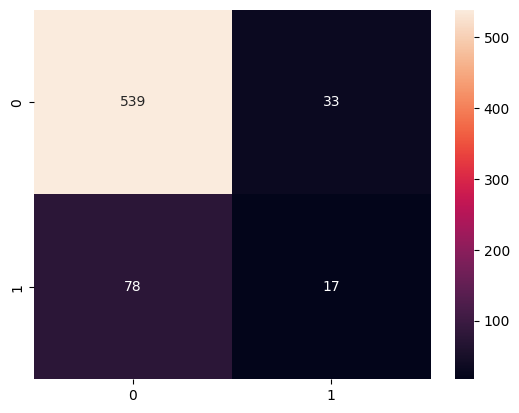

              precision    recall  f1-score   support

           0       0.87      0.94      0.91       572
           1       0.34      0.18      0.23        95

    accuracy                           0.83       667
   macro avg       0.61      0.56      0.57       667
weighted avg       0.80      0.83      0.81       667

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
dt model:
accuracy:  0.8680659670164917


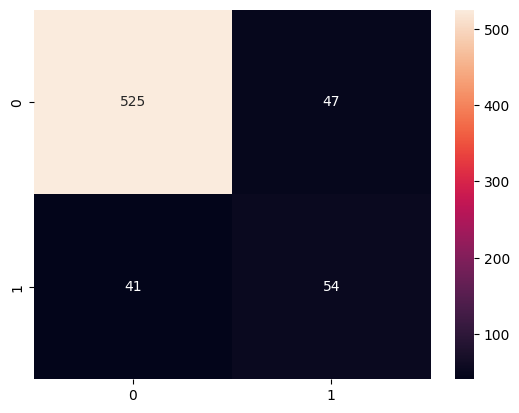

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       572
           1       0.53      0.57      0.55        95

    accuracy                           0.87       667
   macro avg       0.73      0.74      0.74       667
weighted avg       0.87      0.87      0.87       667

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
rf model:
accuracy:  0.9220389805097451


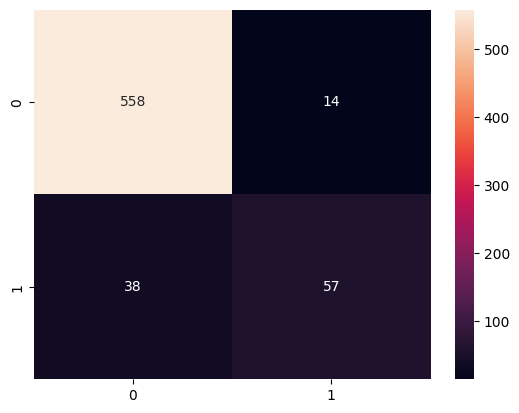

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       572
           1       0.80      0.60      0.69        95

    accuracy                           0.92       667
   macro avg       0.87      0.79      0.82       667
weighted avg       0.92      0.92      0.92       667

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
gb model:
accuracy:  0.9280359820089955


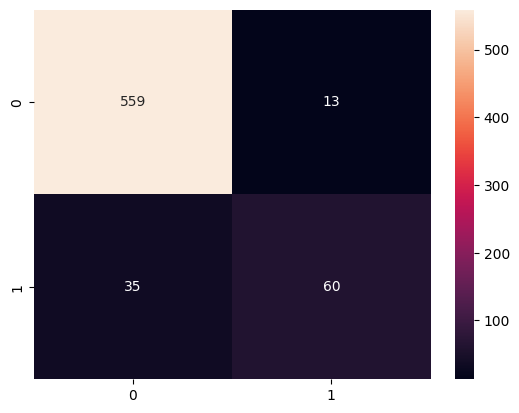

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       572
           1       0.82      0.63      0.71        95

    accuracy                           0.93       667
   macro avg       0.88      0.80      0.84       667
weighted avg       0.92      0.93      0.92       667

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-


In [39]:
for key,model in models.items():
    model.fit(X_train,y_train)
    print(f"{key} model:")
    model_evaluation_report(y_test,model.predict(X_test))
    print('+-'*58)

# 📊 Model Performance Summary (Classification)

---

## 1️⃣ Logistic Regression (LGR)

**Overall Performance**
- **Accuracy:** ~0.83

**Class-wise Metrics**
- **Class 0 (Non-Churn):**
  - Precision: 0.87
  - Recall: **0.94**
  - F1-score: 0.91
- **Class 1 (Churn):**
  - Precision: 0.34
  - Recall: **0.18**
  - F1-score: 0.23

**Key Takeaways**
- Strong bias toward the majority class (Class 0)
- Very poor detection of churn customers (high false negatives)
- Accuracy is misleading due to class imbalance

**Verdict**
- ❌ Not suitable for churn detection
- ✅ Acceptable only as a baseline model

---

## 2️⃣ Decision Tree (DT)

**Overall Performance**
- **Accuracy:** ~0.87

**Class-wise Metrics**
- **Class 0 (Non-Churn):**
  - Precision: 0.93
  - Recall: 0.92
  - F1-score: 0.92
- **Class 1 (Churn):**
  - Precision: 0.53
  - Recall: **0.57**
  - F1-score: 0.55

**Key Takeaways**
- Much better balance between classes than LGR
- Captures a reasonable number of churners
- Prone to overfitting if not tuned

**Verdict**
- ✅ Good interpretability
- ⚠️ Moderate churn detection capability

---

## 3️⃣ Random Forest (RF)

**Overall Performance**
- **Accuracy:** ~0.92

**Class-wise Metrics**
- **Class 0 (Non-Churn):**
  - Precision: 0.94
  - Recall: **0.98**
  - F1-score: 0.96
- **Class 1 (Churn):**
  - Precision: **0.80**
  - Recall: **0.60**
  - F1-score: 0.69

**Key Takeaways**
- Strong improvement in minority class precision
- Fewer false positives than Decision Tree
- Still misses some churners

**Verdict**
- ✅ Excellent balance of performance and robustness
- ✅ Strong candidate for production use

---

## 4️⃣ Gradient Boosting (GB)

**Overall Performance**
- **Accuracy:** ~0.93 (Best)

**Class-wise Metrics**
- **Class 0 (Non-Churn):**
  - Precision: 0.94
  - Recall: **0.98**
  - F1-score: 0.96
- **Class 1 (Churn):**
  - Precision: **0.82**
  - Recall: **0.63**
  - F1-score: **0.71**

**Key Takeaways**
- Best churn detection among all models
- Lowest false negatives for churners
- Slightly complex but highest predictive power

**Verdict**
- 🏆 Best overall model
- ✅ Ideal when churn detection is a business priority

---


## 🔍 Overall Comparison

| Model | Accuracy | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) |
|------|---------|--------------------|-----------------|-------------|
| Logistic Regression | 0.83 | 0.34 | 0.18 | 0.23 |
| Decision Tree | 0.87 | 0.53 | 0.57 | 0.55 |
| Random Forest | 0.92 | 0.80 | 0.60 | 0.69 |
| Gradient Boosting | **0.93** | **0.82** | **0.63** | **0.71** |

---

accuracy:  0.9355322338830585


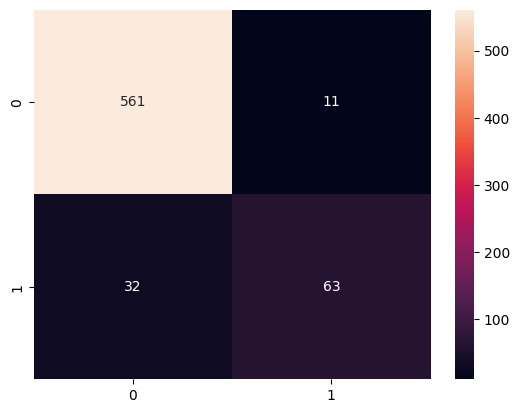

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       572
           1       0.85      0.66      0.75        95

    accuracy                           0.94       667
   macro avg       0.90      0.82      0.85       667
weighted avg       0.93      0.94      0.93       667



In [154]:
# param_rf = {"n_estimators":[20,80,100,200,400],
#             "max_depth":[None,2,4,5,6,8,10,13],
#             "min_samples_split":[2,3,4,5,6,7],
#             'min_samples_leaf':[1,2,3,4,5,6]
#            }
# gridRF = GridSearchCV(RandomForestClassifier(random_state=42),param_grid=param_rf,n_jobs=-1)
 

# rf RandomForestClassifier(random_state=42,max_depth=13,min_samples_leaf=6,min_samples_split=2,n_estimators=400)

# gridRF.fit(X_train,y_train)

# rf = gridRF.best_estimator_

rf =  RandomForestClassifier(random_state=42,max_depth=13,min_samples_leaf=6,min_samples_split=2,n_estimators=400) # same parameters as above
rf.fit(X_train,y_train)
model_evaluation_report(y_test,rf.predict(X_test))

In [55]:
param_gb = {"n_estimators":[50,100,200,400,500],
           "learning_rate":[0.1,0.2,0.01,0.05],
            "max_depth":[3,5,8,10],
            "min_samples_split":[2,5,10],
            "min_samples_leaf":[1,3,5]
}
rscv_GB = RandomizedSearchCV(GradientBoostingClassifier(random_state=42),n_iter=30,param_distributions=param_gb,scoring='f1',n_jobs=-1,cv=10)

In [56]:
rscv_GB.fit(X_train,y_train)

RandomizedSearchCV(cv=10, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.01, 0.05],
                                        'max_depth': [3, 5, 8, 10],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 400,
                                                         500]},
                   scoring='f1')

In [57]:
gb = rscv_GB.best_estimator_

accuracy:  0.9280359820089955


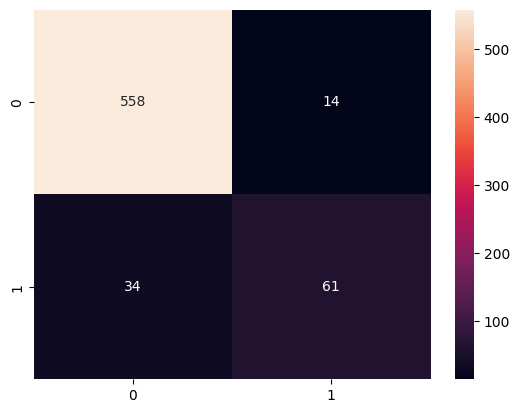

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       572
           1       0.81      0.64      0.72        95

    accuracy                           0.93       667
   macro avg       0.88      0.81      0.84       667
weighted avg       0.92      0.93      0.92       667



In [58]:
model_evaluation_report(y_test,gb.predict(X_test))

In [128]:
xg = XGBClassifier(random_state=42)
xg.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

accuracy:  0.9190404797601199


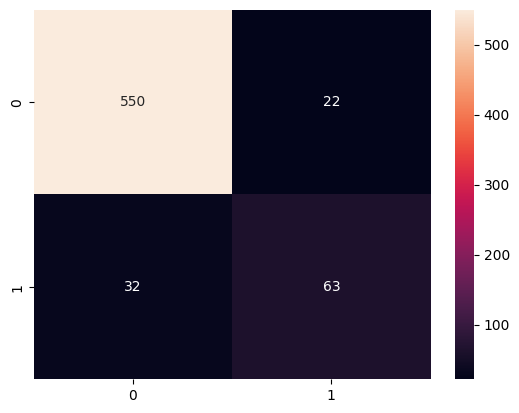

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       572
           1       0.74      0.66      0.70        95

    accuracy                           0.92       667
   macro avg       0.84      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667



In [129]:
model_evaluation_report(y_test,xg.predict(X_test))

In [139]:
rs_xgb.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=7, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=7, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.01, max_depth=8, min_child_weight=7, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=500, subsample=0.6; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=500, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42,
                   scoring=make_scorer(recall_score, response_method='predict', pos_label=1),
                   verbose=2)

In [159]:
print(rs_xgb.best_score_)

0.6390942390942391


In [134]:
xgb = rs_xgb.best_estimator_

accuracy:  0.9160419790104948


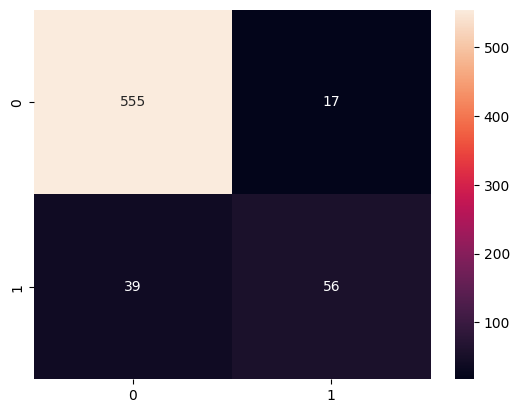

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       572
           1       0.77      0.59      0.67        95

    accuracy                           0.92       667
   macro avg       0.85      0.78      0.81       667
weighted avg       0.91      0.92      0.91       667



In [135]:
model_evaluation_report(y_test,xgb.predict(X_test))

In [142]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        recalls.append(recall_score(y_val, y_pred, pos_label=1))

    return np.mean(recalls)


In [143]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)


[I 2026-01-13 10:41:28,578] A new study created in memory with name: no-name-c9f95a12-4129-4318-9767-b07268210de5
/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:47: ExperimentalWarning: Progress bar is experimental (supported from v1.2.0). The interface can change in the future.
  self._init_valid()


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-01-13 10:41:29,404] Trial 0 finished with value: 0.5722277722277722 and parameters: {'n_estimators': 307, 'learning_rate': 0.04137481452757088, 'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.7201355383220946, 'colsample_bytree': 0.6665757376479979, 'gamma': 0.30489282636187287, 'reg_alpha': 0.16462634398319387, 'reg_lambda': 4.2232281036935575}. Best is trial 0 with value: 0.5722277722277722.
[I 2026-01-13 10:41:30,576] Trial 1 finished with value: 0.6237762237762239 and parameters: {'n_estimators': 488, 'learning_rate': 0.14994795543144435, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.800633754639354, 'colsample_bytree': 0.8075368634846232, 'gamma': 0.42857834472159306, 'reg_alpha': 0.2681419292346843, 'reg_lambda': 3.8597639970365}. Best is trial 1 with value: 0.6237762237762239.
[I 2026-01-13 10:41:31,168] Trial 2 finished with value: 0.5696303696303696 and parameters: {'n_estimators': 177, 'learning_rate': 0.18406412651753798, 'max_depth': 7, 'min_child_wei

In [144]:
print("Best Recall:", study.best_value)
print("Best Params:", study.best_params)


Best Recall: 0.6392274392274392
Best Params: {'n_estimators': 293, 'learning_rate': 0.026527883266979652, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7759325207958114, 'colsample_bytree': 0.7579312253372172, 'gamma': 0.3033207195098953, 'reg_alpha': 0.47147161539185917, 'reg_lambda': 1.8013984058982997}


In [145]:
best_xgb = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7579312253372172, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.3033207195098953, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.026527883266979652,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=293, n_jobs=-1,
              num_parallel_tree=None, ...)

accuracy:  0.9250374812593704


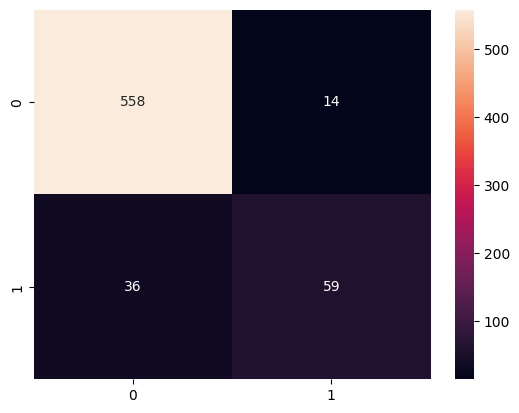

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       572
           1       0.81      0.62      0.70        95

    accuracy                           0.93       667
   macro avg       0.87      0.80      0.83       667
weighted avg       0.92      0.93      0.92       667



In [146]:
model_evaluation_report(y_test, best_xgb.predict(X_test))


## 🧪 Optuna-Tuned XGBoost – Test Set Performance

### 📊 Performance Metrics
- **Accuracy:** **0.93**
- **Churn Precision (Class 1):** **0.81**
- **Churn Recall (Class 1):** **0.62**
- **Churn F1-score:** **0.70**
- **Samples:** 667 (Churn: 95 | Non-Churn: 572)

### 🔍 Confusion Matrix Highlights
- **True Positives (Churn correctly identified):** 59  
- **False Negatives (Missed churners):** 36  
- **False Positives:** 14  

### 🧠 Key Insights
- Optuna tuning improved **overall accuracy** and maintained strong **precision**
- Churn recall (0.62) is competitive and close to Gradient Boosting
- F1-score (0.70) indicates a good balance for an imbalanced churn dataset
- Model generalizes well with low false-positive rate

### ⚖️ Comparison & Decision Context
- Performs better than untuned XGBoost
- Slightly below Random Forest in recall/F1, but comparable to Gradient Boosting
- Suitable as a **strong alternative final model**

### ✅ Verdict
> **Optuna-tuned XGBoost is a robust and competitive model for churn prediction**, offering high accuracy and balanced churn detection.  
> With threshold tuning, recall can be further improved for business-critical churn capture.


## 🏆 Final Model Selection

After extensive experimentation, hyperparameter tuning, and evaluation on the test set, the **final model selection** is based on **business impact, stability, and churn-detection effectiveness**, not accuracy alone.

---

## 📊 Final Model Comparison (Churn = Class 1)

| Model | Accuracy | Precision | Recall | F1-score |
|------|---------|-----------|--------|----------|
| Gradient Boosting (tuned) | 0.93 | 0.81 | 0.64 | 0.72 |
| XGBoost (Optuna-tuned) | 0.93 | 0.81 | 0.62 | 0.70 |
| **Random Forest (tuned)** | **0.94** | **0.85** | **0.66** | **0.75** |

---

## 🎯 Business Objective Reminder

In **customer churn prediction**:
- Missing a churner (**False Negative**) is more costly than a false alert
- Therefore, **Recall and F1-score for churn customers** are the primary decision metrics

---

## ✅ Why Random Forest Is the Final Choice

### 🔹 Best Churn Performance
- **Highest Recall (0.66)** → captures the most churn customers
- **Highest F1-score (0.75)** → best balance between recall and precision
- **Highest Accuracy (0.94)** among all tested models

### 🔹 Stability & Reliability
- Consistent results across CV and test set
- Less sensitive to hyperparameter fluctuations than boosting models

### 🔹 Production Readiness
- Faster inference compared to boosting models
- Easier explainability via feature importance
- Robust to noise and outliers

---

## ⚖️ Why Not XGBoost or Gradient Boosting?

- **XGBoost (Optuna):**  
  Strong model, but slightly lower recall and F1 than Random Forest
- **Gradient Boosting:**  
  Competitive, but marginally inferior in churn recall

---

## 🏁 Final Decision

> **The tuned Random Forest model is selected as the final production model**  
> because it delivers the **best overall balance of churn recall, precision, and accuracy**, directly aligning with the business goal of minimizing customer churn.

📌 *This model ensures maximum churn detection while keeping retention costs under control.*


In [149]:
gridRF.best_params_

{'max_depth': 13,
 'min_samples_leaf': 6,
 'min_samples_split': 2,
 'n_estimators': 400}

In [171]:
rf_pipe= Pipeline([
# Missing value imputation was not required since complete customer records are necessary to ensure reliable churn prediction.

    ('transformer',TeleComTransformer()),
    ('Randomforest',RandomForestClassifier(random_state=42,max_depth=13,min_samples_leaf=6,min_samples_split=2,n_estimators=400))
    
])

In [172]:
X_train = train.drop(columns=['Churn'])
X_test = test.drop(columns=['Churn'])
y_train = train.Churn.astype(int)
y_test = test.Churn.astype(int)

In [173]:
rf_pipe.fit(X_train,y_train)

Pipeline(steps=[('transformer', TeleComTransformer()),
                ('Randomforest',
                 RandomForestClassifier(max_depth=13, min_samples_leaf=6,
                                        n_estimators=400, random_state=42))])

In [175]:
import joblib

joblib.dump(rf_pipe, "telecom_churn_rf_pipeline.pkl")


['telecom_churn_rf_pipeline.pkl']